# Multi-Agent ChatBot — AI-Powered Learning Assistant

## Overview

**Multi-Agent ChatBot** is an agentic AI system that routes user questions to specialised chatbot agents — each an expert in its own domain. It is built entirely with open-source tools and runs fully locally — no paid API keys or cloud services are required.

Currently available agents:

| Agent | Domain |
|---|---|
| 🏥 **HealthBot** | Medical conditions, symptoms, treatments, wellness |
| 💻 **QualityBot** | Software quality, testing, QA, standards, best practices |

---

## How It Works

The system uses a [LangGraph](https://github.com/langchain-ai/langgraph) state machine with an **LLM-based router** that classifies the user's topic and delegates to the appropriate specialist agent:

1. **Topic input** — the user enters any topic or question
2. **Classification** — the LLM classifies the topic into a domain (`health` or `sw_quality`)
3. **Routing** — the graph branches to the matching specialist agent
4. **Web search** — two focused DuckDuckGo searches are run to retrieve up-to-date information
5. **Summarisation** — a local LLM (via [Ollama](https://ollama.com)) condenses the search results into a clear, accessible summary
6. **Quiz** — the LLM generates one short-answer question derived solely from the summary
7. **Grading** — the user's answer is evaluated and graded (A–F) with a written justification
8. **Loop** — the user can continue with a new topic (possibly routed to a different agent) or end the session

The graph flow:

```
START → get_topic → classify_topic ─┬─► search_health      → summarize_health      ─┐
                                    └─► search_sw_quality   → summarize_sw_quality   ─┤
                                                                                      ▼
                                                                              present_summary
                                                                                      │
      prompt_ready_for_quiz → generate_quiz → present_quiz → collect_answer           │
              ▲                                                     │                 │
              └─────────────────────────────────────────────────────┘                 │
                                                                                      ▼
      evaluate_answer → present_result → ask_continue ──► yes → get_topic
                                                     └──► no  → END
```

---

## Tech Stack

| Component | Technology |
|---|---|
| Agentic framework | LangGraph |
| LLM backend | Ollama (`llama3.1:8b` by default — swap in any model you have pulled) |
| Topic routing | LLM-based classifier (zero-shot domain classification) |
| Web search | `ddgs` — DuckDuckGo search, called directly (no API key required) |
| Chat UI | ipywidgets (fixed-height chat panel pinned in the cell output) |
| Persistence / checkpointing | LangGraph `MemorySaver` |

---

## Notebook Structure

| Cell | Purpose |
|---|---|
| 2 | **Configuration** — set the Ollama model name and base URL here |
| 3 | **Scaffolding** — imports, `ChatBotUI` widget class, `ChatOllama` model instance |
| 4 | **Multi-Agent Graph** — search helpers, LangGraph nodes (router + both specialist agents), and graph factory |
| 5 | **Runner** — renders the chat panel and starts the session (run this last) |

---

## Adding More Agents

To add a new specialist agent:

1. Add an entry to `AGENT_LABELS` (e.g. `"devops": "🔧 DevOpsBot"`)
2. Create `search_<domain>()` and `summarize_<domain>()` node functions
3. Register them as nodes in `build_chatbot()` and wire the edges
4. Add the new domain to the classifier's system prompt in `classify_topic()`

---

> ⚠️ **Disclaimer:** This chatbot is an educational tool only. All information is sourced from public websites and summarised by a local AI model. The HealthBot agent is **not** a substitute for professional medical advice, diagnosis, or treatment.

In [5]:
OLLAMA_MODEL = "llama3.1:8b"   # change to "mistral", "gemma3", etc. if preferred
OLLAMA_BASE_URL = "http://localhost:11434"  # default Ollama address


In [6]:
import threading
import queue as stdlib_queue
import ipywidgets as widgets
from langgraph.graph import MessagesState, START, StateGraph, END
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables import RunnableConfig
from IPython.display import Image, display


# ── Chat UI ───────────────────────────────────────────────────────────────────

class ChatBotUI:
    """Widget-based chat interface for the multi-agent chatbot.

    Layout: a fixed-height (600px) VBox so the input bar is always visible
    at the bottom without any page scrolling. The message area fills the
    remaining space and scrolls internally. An inline <script> tag appended
    to the HTML on every update auto-scrolls to the latest message.

    Input sync: stdlib queue.Queue — the graph runs in a background thread
    and blocks on queue.get(); the widget callback puts the value from the
    kernel's event loop, unblocking the graph thread.
    """

    _BOT_STYLE  = "background:#e8f4fd;border-radius:8px;padding:8px 12px;margin:4px 0;font-family:sans-serif;"
    _USER_STYLE = "background:#f0f0f0;border-radius:8px;padding:8px 12px;margin:4px 0;text-align:right;font-family:sans-serif;"
    _INFO_STYLE = "color:#777;font-style:italic;font-size:0.88em;margin:2px 6px;font-family:sans-serif;"
    _HEAD_STYLE = "color:#2c7bb6;border-bottom:1px solid #ddd;padding-bottom:4px;margin:10px 0 6px;font-family:sans-serif;"

    # Scroll-to-bottom script: walks up from the <script> tag to the first
    # scrollable ancestor (the msg_area widget div) and sets scrollTop.
    _SCROLL_JS = (
        "<script>try{var s=document.currentScript,p=s.parentElement;"
        "while(p&&!(p.scrollHeight>p.clientHeight))p=p.parentElement;"
        "if(p)p.scrollTop=p.scrollHeight;}catch(e){}</script>"
    )

    def __init__(self):
        self._input_queue = stdlib_queue.Queue()
        self._html_buffer = ""
        self._allow_empty = False

        # Message area: flex="1 1 auto" so it fills all space above the input bar.
        self.msg_area = widgets.HTML(
            value="",
            layout=widgets.Layout(
                flex="1 1 auto",
                overflow_y="auto",
                padding="12px",
                border="1px solid #ddd",
                border_radius="8px 8px 0 0",
            ),
        )

        self.text_input = widgets.Text(
            placeholder="Type your answer and press Enter or click Submit…",
            disabled=True,
            layout=widgets.Layout(flex="1"),
        )

        self.submit_btn = widgets.Button(
            description="Submit",
            button_style="primary",
            disabled=True,
            layout=widgets.Layout(width="110px"),
        )

        self.submit_btn.on_click(self._on_submit)
        self.text_input.on_submit(lambda _: self._on_submit(None))

        # Input bar: flex="0 0 auto" so it never shrinks; always visible at bottom.
        input_row = widgets.HBox(
            [self.text_input, self.submit_btn],
            layout=widgets.Layout(
                flex="0 0 auto",
                padding="8px",
                border="1px solid #ddd",
                border_top="none",
                border_radius="0 0 8px 8px",
                background_color="#f8f8f8",
            ),
        )

        # Fixed-height outer container — the page never needs to scroll.
        self._container = widgets.VBox(
            [self.msg_area, input_row],
            layout=widgets.Layout(height="600px"),
        )

    def show(self):
        """Render the chat panel in the current cell output."""
        display(self._container)

    # ── Widget callback (runs on kernel event-loop thread) ────────────────────

    def _on_submit(self, _):
        value = self.text_input.value.strip()
        if not value and not self._allow_empty:
            return
        self.text_input.value = ""
        self._input_queue.put(value)

    # ── Thread-safe display helpers ───────────────────────────────────────────

    def _append(self, html: str):
        """Append an HTML fragment, update the widget, and auto-scroll to bottom."""
        self._html_buffer += html
        # Appending _SCROLL_JS on every update scrolls the message area to the
        # bottom so the latest message is always in view without manual scrolling.
        self.msg_area.value = self._html_buffer + self._SCROLL_JS

    def _escape_html(self, text: str) -> str:
        """Escape user/LLM text for safe inclusion in HTML, preserving newlines."""
        if text is None:
            return ""
        escaped = text.replace("&", "&amp;")
        escaped = escaped.replace("<", "&lt;")
        escaped = escaped.replace(">", "&gt;")
        escaped = escaped.replace('"', "&quot;")
        escaped = escaped.replace("'", "&#x27;")
        return escaped.replace("\n", "<br>")

    def bot_message(self, text: str, bot_name: str = "🤖 Bot"):
        """Display a bot message bubble with a configurable agent name."""
        safe_text = self._escape_html(text)
        safe_name = self._escape_html(bot_name)
        self._append(f"<div style='{self._BOT_STYLE}'><b>{safe_name}:</b> {safe_text}</div>")

    def user_message(self, text: str):
        """Display the user's echoed reply bubble."""
        safe_text = self._escape_html(text)
        self._append(f"<div style='{self._USER_STYLE}'><b>👤 You:</b> {safe_text}</div>")

    def system_message(self, text: str):
        """Display a dimmed status / progress line."""
        safe_text = self._escape_html(text)
        self._append(f"<p style='{self._INFO_STYLE}'>{safe_text}</p>")

    def header(self, text: str):
        """Display a section header."""
        safe_text = self._escape_html(text)
        self._append(f"<h3 style='{self._HEAD_STYLE}'>{safe_text}</h3>")

    def clear(self):
        """Clear the message history."""
        self._html_buffer = ""
        self.msg_area.value = ""

    # ── Blocking input (call from background thread only) ─────────────────────

    def get_input(self, prompt: str, allow_empty: bool = False) -> str:
        """Enable the input bar and block the calling thread until the user submits.

        Must be called from the graph's background thread, NOT from the
        kernel's event-loop thread — otherwise queue.get() would block the
        kernel.

        If *allow_empty* is True the user may press Submit / Enter without
        typing anything (useful for "press Enter to continue" prompts).
        """
        self.system_message(prompt)
        self._allow_empty = allow_empty
        self.text_input.disabled = False
        self.submit_btn.disabled = False
        value = self._input_queue.get()   # blocks graph thread; kernel loop stays free
        self.text_input.disabled = True
        self.submit_btn.disabled = True
        self._allow_empty = False
        if isinstance(value, str) and value:
            self.user_message(value)
        return value


# ── LLM model ─────────────────────────────────────────────────────────────────

# client_kwargs is forwarded to httpx.Client. timeout=120 ensures the LLM call
# raises a ReadTimeout instead of hanging indefinitely if Ollama is unresponsive.

model = ChatOllama(
    model=OLLAMA_MODEL,
    client_kwargs={"timeout": 120},
    base_url=OLLAMA_BASE_URL,
    temperature=0,
)

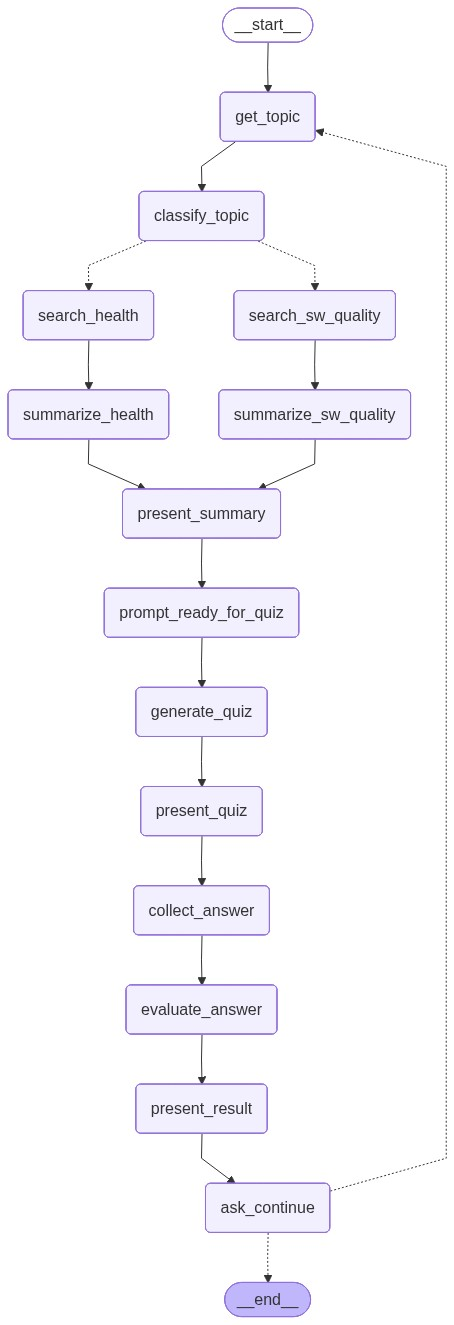

In [7]:
# Multi-Agent ChatBot — Router + HealthBot + QualityBot
import warnings

# Suppress deprecation/runtime warnings from the duckduckgo_search → ddgs migration.
warnings.filterwarnings("ignore", category=RuntimeWarning, module="ddgs")
warnings.filterwarnings("ignore", category=UserWarning,    module="ddgs")

from ddgs import DDGS
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage


# ── Search tools ──────────────────────────────────────────────────────────────

def search_medical(query: str) -> str:
    """Run two focused DuckDuckGo searches and return combined results.

    Two focused sub-queries are used instead of one generic query:
    - 'overview & symptoms'  → covers what the condition is and how it presents
    - 'treatment & prevention' → covers management and lifestyle options

    This structure ensures the LLM receives relevant content for all four
    sections it is asked to write (what / symptoms / treatment / prevention).

    Note: site: filters are intentionally omitted — DuckDuckGo does not
    support them reliably and they degrade result quality in practice.
    """
    with DDGS() as d:
        overview_hits   = list(d.text(f"{query} medical condition what is it symptoms causes", max_results=6))
        management_hits = list(d.text(f"{query} treatment options prevention management",     max_results=6))

    def _fmt(hits):
        return "\n".join(f"[{h['title']}]: {h['body']}" for h in hits)

    return (
        f"=== Overview & Symptoms ===\n{_fmt(overview_hits)}\n\n"
        f"=== Treatment & Prevention ===\n{_fmt(management_hits)}"
    )


def search_sw_quality(query: str) -> str:
    """Run two focused DuckDuckGo searches for software quality information."""
    with DDGS() as d:
        concepts_hits = list(d.text(f"{query} software quality definition best practices", max_results=6))
        methods_hits  = list(d.text(f"{query} software quality methods tools standards",   max_results=6))

    def _fmt(hits):
        return "\n".join(f"[{h['title']}]: {h['body']}" for h in hits)

    return (
        f"=== Concepts & Best Practices ===\n{_fmt(concepts_hits)}\n\n"
        f"=== Methods, Tools & Standards ===\n{_fmt(methods_hits)}"
    )


# ── State ─────────────────────────────────────────────────────────────────────

class ChatBotState(MessagesState):
    topic: str = ""
    domain: str = ""               # "health" | "sw_quality"
    search_results: str = ""
    summary: str = ""
    quiz_question: str = ""
    patient_answer: str = ""
    grade_and_explanation: str = ""
    continue_session: bool = False


# ── Agent labels (extend this dict to add more agents) ────────────────────────

AGENT_LABELS = {
    "health":     "🏥 HealthBot",
    "sw_quality": "💻 QualityBot",
}


# ── Nodes ─────────────────────────────────────────────────────────────────────
# Nodes are regular (sync) functions. They run in a background thread
# (started by the runner cell) and may block on ui.get_input() without
# freezing the kernel's event loop.

def get_topic(state: ChatBotState):
    """Collect the topic from the user."""
    ui.clear()
    ui.header("Welcome to Multi-Agent ChatBot")
    ui.bot_message(
        "I can help you learn about:\n"
        "• Health topics and medical conditions (HealthBot)\n"
        "• Software quality topics (QualityBot)\n\n"
        "Just ask your question and I'll route you to the right expert!",
        bot_name="🤖 Router",
    )
    topic = ui.get_input("What would you like to learn about?")
    return {
        "topic": topic,
        "domain": "",
        "search_results": "",
        "summary": "",
        "quiz_question": "",
        "patient_answer": "",
        "grade_and_explanation": "",
        "messages": [HumanMessage(content=f"I would like to learn about: {topic}")]
    }


def classify_topic(state: ChatBotState):
    """Use the LLM to classify the user's topic into a domain."""
    messages = [
        SystemMessage(content=(
            "You are a topic classifier. Given a user's question or topic, "
            "classify it into exactly ONE of these domains:\n"
            "- health: anything related to medical conditions, diseases, symptoms, "
            "  treatments, wellness, nutrition, mental health, fitness\n"
            "- sw_quality: anything related to software quality, testing, QA, "
            "  code reviews, CI/CD, software metrics, coding standards, "
            "  software engineering best practices, ISO 25010, bugs, defects\n\n"
            "Respond with ONLY the domain label (health or sw_quality), nothing else."
        )),
        HumanMessage(content=f"Topic: {state['topic']}")
    ]
    response = model.invoke(messages)
    domain = response.content.strip().lower()
    # Fallback: if LLM returns something unexpected, default to health
    if domain not in AGENT_LABELS:
        domain = "health"
    ui.system_message(f"Routing to {AGENT_LABELS[domain]}…")
    return {"domain": domain}


def route_domain(state: ChatBotState) -> str:
    """Route to the appropriate search node based on classified domain."""
    return f"search_{state['domain']}"


# ── Health branch ─────────────────────────────────────────────────────────────

def search_health(state: ChatBotState):
    """Search DuckDuckGo for medical information on the topic."""
    ui.system_message(f"🔍 Searching for health information about '{state['topic']}'…")
    combined = search_medical(state['topic'])
    return {
        "search_results": combined,
        "messages": [AIMessage(content=f"[Search results for '{state['topic']}']:\n{combined}")]
    }


def summarize_health(state: ChatBotState):
    """Use the LLM to produce a patient-friendly summary from search results only."""
    ui.system_message("📝 Summarizing health information for you…")
    messages = [
        SystemMessage(content=(
            "You are a compassionate medical educator. "
            "IMPORTANT: Base your summary EXCLUSIVELY on the search results provided below. "
            "Do NOT use any prior knowledge, training data, or external information beyond what is given. "
            "Summarize the provided information in a clear, patient-friendly way using simple language and avoiding jargon. "
            "Write exactly 3 to 4 paragraphs (no bullet points, no headings). "
            "Cover in order: (1) what the condition is, (2) common symptoms, "
            "(3) treatment options, and (4) prevention tips — drawn only from the search results."
        )),
        HumanMessage(content=f"Topic: {state['topic']}\n\nSearch Results:\n{state['search_results']}")
    ]
    response = model.invoke(messages)
    return {
        "summary": response.content,
        "messages": [AIMessage(content=f"[Summary of '{state['topic']}']:\n{response.content}")]
    }


# ── Software Quality branch ──────────────────────────────────────────────────

# Preserve the existing search helper before defining the canonical node.
_search_sw_quality_tool = search_sw_quality

def search_sw_quality(state: ChatBotState):
    """Search DuckDuckGo for software quality information on the topic."""
    ui.system_message(f"🔍 Searching for software quality information about '{state['topic']}'…")
    combined = _search_sw_quality_tool(state['topic'])
    return {
        "search_results": combined,
        "messages": [AIMessage(content=f"[Search results for '{state['topic']}']:\n{combined}")]
    }


def search_sw_quality_node(state: ChatBotState):
    """Backward-compatible wrapper for older references to the SW-quality search node."""
    return search_sw_quality(state)


def summarize_sw_quality(state: ChatBotState):
    """Use the LLM to produce a professional summary of software quality information."""
    ui.system_message("📝 Summarizing software quality information for you…")
    messages = [
        SystemMessage(content=(
            "You are a knowledgeable software quality expert and educator. "
            "IMPORTANT: Base your summary EXCLUSIVELY on the search results provided below. "
            "Do NOT use any prior knowledge, training data, or external information beyond what is given. "
            "Summarize the provided information in a clear, professional yet accessible way. "
            "Write exactly 3 to 4 paragraphs (no bullet points, no headings). "
            "Cover in order: (1) what the concept or practice is, (2) why it matters for software quality, "
            "(3) common methods, tools, or standards related to it, and "
            "(4) practical tips for implementation — drawn only from the search results."
        )),
        HumanMessage(content=f"Topic: {state['topic']}\n\nSearch Results:\n{state['search_results']}")
    ]
    response = model.invoke(messages)
    return {
        "summary": response.content,
        "messages": [AIMessage(content=f"[Summary of '{state['topic']}']:\n{response.content}")]
    }


# ── Shared nodes (domain-agnostic) ───────────────────────────────────────────

def present_summary(state: ChatBotState):
    """Display the LLM-generated summary to the user."""
    label = AGENT_LABELS.get(state['domain'], "🤖 Bot")
    ui.header(f"{label}: {state['topic']}")
    ui.bot_message(state['summary'], bot_name=label)
    return {"summary": state["summary"]}


def prompt_ready_for_quiz(state: ChatBotState):
    """Ask the user to confirm they are ready for the comprehension check."""
    ui.get_input("Press Enter or click Submit when you are ready for the quiz.", allow_empty=True)
    return {"summary": state["summary"]}


def generate_quiz(state: ChatBotState):
    """Use the LLM to generate one quiz question based on the summary only."""
    label = AGENT_LABELS.get(state['domain'], "🤖 Bot")
    ui.system_message(f"🧠 {label} is generating your quiz question…")
    messages = [
        SystemMessage(content=(
            "You are an educator. "
            "IMPORTANT: Create your quiz question EXCLUSIVELY from the summary provided below. "
            "Do NOT draw on any outside knowledge — the question must be fully answerable "
            "using only the information contained in that summary. "
            "Create ONE clear, short-answer question that tests understanding of a key concept. "
            "Provide just the question, nothing else."
        )),
        HumanMessage(content=f"Topic: {state['topic']}\n\nSummary:\n{state['summary']}")
    ]
    response = model.invoke(messages)
    return {
        "quiz_question": response.content,
        "messages": [AIMessage(content=f"[Quiz question]:\n{response.content}")]
    }


def present_quiz(state: ChatBotState):
    """Display the quiz question to the user."""
    ui.header("Comprehension Check")
    label = AGENT_LABELS.get(state['domain'], "🤖 Bot")
    ui.bot_message(state['quiz_question'], bot_name=label)
    return {"quiz_question": state["quiz_question"]}


def collect_answer(state: ChatBotState):
    """Collect the user's answer to the quiz question."""
    answer = ui.get_input("Your answer:")
    return {
        "patient_answer": answer,
        "messages": [HumanMessage(content=f"[Answer]:\n{answer}")]
    }


def evaluate_answer(state: ChatBotState):
    """Use the LLM to grade the user's answer against the summary only."""
    ui.system_message("✅ Evaluating your answer…")
    system = SystemMessage(content=(
        "You are a supportive educator grading an answer. "
        "IMPORTANT: Evaluate the answer EXCLUSIVELY using the summary provided below as your only reference. "
        "Do NOT use any outside knowledge beyond what appears in that summary. "
        "Assign a letter grade using this scale:\n"
        "  A — Fully correct and complete based on the summary\n"
        "  B — Mostly correct with minor gaps or inaccuracies\n"
        "  C — Partially correct but missing key details from the summary\n"
        "  D — Minimal understanding shown; answer is largely incorrect\n"
        "  F — Incorrect, irrelevant, or blank\n\n"
        "Format your response exactly as:\n"
        "Grade: [A / B / C / D / F]\n\n"
        "Justification: [Explain why you gave this grade, citing specific points "
        "from the summary to support your evaluation]"
    ))
    grading_prompt = HumanMessage(content=(
        f"Topic: {state['topic']}\n\n"
        f"Summary provided:\n{state['summary']}\n\n"
        f"Quiz question:\n{state['quiz_question']}\n\n"
        f"Answer:\n{state['patient_answer']}"
    ))
    response = model.invoke([system, grading_prompt])
    return {
        "grade_and_explanation": response.content,
        "messages": [AIMessage(content=f"[Grade and justification]:\n{response.content}")]
    }


def present_result(state: ChatBotState):
    """Display the grade and justification to the user."""
    ui.header("Your Results")
    label = AGENT_LABELS.get(state['domain'], "🤖 Bot")
    ui.bot_message(state['grade_and_explanation'], bot_name=label)
    return {"grade_and_explanation": state["grade_and_explanation"]}


def ask_continue(state: ChatBotState):
    """Ask the user whether to learn about a new topic or exit."""
    choice = ui.get_input("Would you like to learn about another topic? (yes / no)")
    return {"continue_session": choice.strip().lower() in ['yes', 'y']}


def route_continue(state: ChatBotState) -> str:
    """Conditional edge: restart the graph at get_topic or end the session."""
    return "get_topic" if state.get("continue_session") else END


# ── Graph factory ─────────────────────────────────────────────────────────────
# To add a new specialist agent:
#   1. Add an entry to AGENT_LABELS
#   2. Create search_<domain> and summarize_<domain> functions
#   3. Register them as nodes below and wire the edges

def build_chatbot():
    wf = StateGraph(ChatBotState)

    # Shared entry
    wf.add_node("get_topic",       get_topic)
    wf.add_node("classify_topic",  classify_topic)

    # Health branch
    wf.add_node("search_health",     search_health)
    wf.add_node("summarize_health",  summarize_health)

    # Software Quality branch
    wf.add_node("search_sw_quality",     search_sw_quality_node)
    wf.add_node("summarize_sw_quality",  summarize_sw_quality)

    # Shared post-summary nodes
    wf.add_node("present_summary",       present_summary)
    wf.add_node("prompt_ready_for_quiz", prompt_ready_for_quiz)
    wf.add_node("generate_quiz",         generate_quiz)
    wf.add_node("present_quiz",          present_quiz)
    wf.add_node("collect_answer",        collect_answer)
    wf.add_node("evaluate_answer",       evaluate_answer)
    wf.add_node("present_result",        present_result)
    wf.add_node("ask_continue",          ask_continue)

    # Entry → Router
    wf.add_edge(START,          "get_topic")
    wf.add_edge("get_topic",    "classify_topic")

    # Router → domain-specific branch
    wf.add_conditional_edges("classify_topic", route_domain, {
        "search_health":     "search_health",
        "search_sw_quality": "search_sw_quality",
    })

    # Health branch → shared
    wf.add_edge("search_health",    "summarize_health")
    wf.add_edge("summarize_health", "present_summary")

    # SW Quality branch → shared
    wf.add_edge("search_sw_quality",    "summarize_sw_quality")
    wf.add_edge("summarize_sw_quality", "present_summary")

    # Shared continuation
    wf.add_edge("present_summary",       "prompt_ready_for_quiz")
    wf.add_edge("prompt_ready_for_quiz", "generate_quiz")
    wf.add_edge("generate_quiz",         "present_quiz")
    wf.add_edge("present_quiz",          "collect_answer")
    wf.add_edge("collect_answer",        "evaluate_answer")
    wf.add_edge("evaluate_answer",       "present_result")
    wf.add_edge("present_result",        "ask_continue")

    wf.add_conditional_edges("ask_continue", route_continue, {"get_topic": "get_topic", END: END})

    return wf.compile(checkpointer=MemorySaver())


# Display graph diagram to verify structure before running
chatbot_app = build_chatbot()
display(Image(chatbot_app.get_graph().draw_mermaid_png()))

In [8]:
import asyncio as _asyncio
import traceback as _traceback

# Run Multi-Agent ChatBot
#
# Cell returns immediately after starting the background thread so the
# kernel is no longer "busy" and VS Code will dispatch widget comm
# messages (button clicks / Enter key) to _on_submit().
# The graph thread blocks on queue.Queue.get() until the user submits,
# which _on_submit() unblocks via queue.put().

# ── Cancel any previous session still running ────────────────────────────────
# If this cell is re-run while a previous session is active (e.g. after a
# failed run), the old background thread would keep the old UI alive. Unblock
# it by injecting a sentinel value, then wait briefly for it to exit.
_SENTINEL = object()
if "_hb_thread" in dir() and _hb_thread.is_alive():   # noqa: F821
    try:
        _hb_ui._input_queue.put(_SENTINEL)             # noqa: F821
        _hb_thread.join(timeout=3)                     # noqa: F821
    except Exception:
        pass

# ── Fresh session ─────────────────────────────────────────────────────────────

ui = ChatBotUI()
ui.show()

session_app = build_chatbot()
hb_config = RunnableConfig(
    recursion_limit=2000,
    configurable={"thread_id": "session"}
)

def _run_graph():
    loop = _asyncio.new_event_loop()
    _asyncio.set_event_loop(loop)
    try:
        session_app.invoke({"messages": []}, hb_config)
        ui.bot_message("Thank you for using the Multi-Agent ChatBot. See you next time!", bot_name="🤖 Router")
    except Exception as exc:
        err = _traceback.format_exc()
        print(err, flush=True)   # always visible in cell stderr
        safe = (err.replace("&", "&amp;")
                   .replace("<", "&lt;")
                   .replace("\n", "<br>")
                   .replace(" ", "&nbsp;"))
        safe_exc = str(exc).replace("&", "&amp;").replace("<", "&lt;")
        ui.bot_message(f"⚠️ Session ended with an error: <code>{safe_exc}</code>")
        ui.system_message(safe)
    finally:
        loop.close()

_hb_ui = ui

# Patch get_input before starting the thread so every blocking queue.get()
# is sentinel-aware, including in-flight calls on re-run.
_orig_get_input = ui.get_input
def _get_input_with_sentinel(prompt: str, **kwargs) -> str:
    val = _orig_get_input(prompt, **kwargs)
    if val is _SENTINEL:
        raise SystemExit("Session cancelled by re-run.")
    return val
ui.get_input = _get_input_with_sentinel

_hb_thread = threading.Thread(target=_run_graph, daemon=True)
_hb_thread.start()
# ↑ Returns immediately — graph continues in background.

/tmp/ipykernel_13520/246653337.py:70: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  self.text_input.on_submit(lambda _: self._on_submit(None))
